In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Wrangling

In [3]:
df = pd.read_csv("Salary_dataset.csv")
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [4]:
df.shape

(30, 3)

In [5]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [7]:
df = df.drop(columns=["Unnamed: 0"])

In [8]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [9]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='str')

In [10]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

## EDA

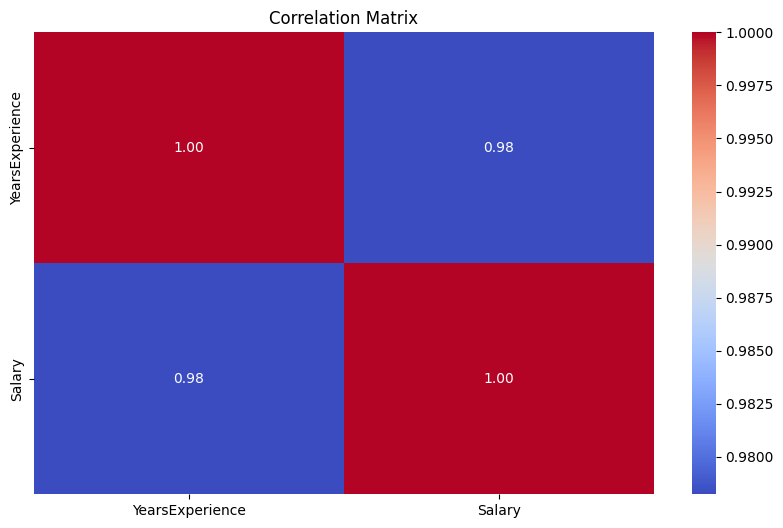

In [11]:
plt.figure(figsize=(10, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Train-test split

In [12]:
from sklearn.model_selection import train_test_split

X, y = df["YearsExperience"].values, df["Salary"].values

X, y = X.reshape(-1, 1), y.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
X.shape

(30, 1)

In [14]:
X_train.shape

(24, 1)

In [15]:
X_test.shape

(6, 1)

## Training

In [16]:
class UnivariateLinearRegressor:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta = None
        self.MSE_loss_history = []
        self.theta_history = []
    
    def MSE_loss(self, y_pred, y):
        m = y.shape[0]
        loss = (1 / (2*m)) * np.sum((y_pred - y)**2)
        return loss
    
    def gradient_descent(self, X, y, y_pred, theta):
        m = y.shape[0]
        gradient_0 = np.sum(y_pred - y) / m
        gradient_1 = np.sum(np.dot((y_pred - y).T, X[:, 1])) / m

        theta[0] = theta[0] - self.learning_rate*gradient_0
        theta[1] = theta[1] - self.learning_rate*gradient_1

        return theta

    def fit(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        new_dimension = np.ones((X.shape[0], 1))
        X = np.hstack((new_dimension, X))

        self.theta = np.zeros((X.shape[1], 1))

        for i in range(self.n_iters):
            y_pred = np.dot(X, self.theta)
            loss = self.MSE_loss(y_pred, y)
            self.MSE_loss_history.append(loss)
            self.theta_history.append(self.theta)

            if i % 100 == 0:
                print(f"Iteration {i}: MSE loss = {loss}")
            
            self.theta = self.gradient_descent(X, y, y_pred, self.theta)
        
        return self.theta
    
    def predict(self, X: np.ndarray, theta: np.ndarray) -> np.ndarray:
        new_dimension = np.ones((X.shape[0], 1))
        X = np.hstack((new_dimension, X))
        predictions = np.dot(X, theta)
        return predictions

In [17]:
myModel = UnivariateLinearRegressor(learning_rate=0.01, n_iters=1000)
theta = myModel.fit(X_train, y_train)

Iteration 0: MSE loss = 3135614129.3541665
Iteration 100: MSE loss = 50593271.58168006
Iteration 200: MSE loss = 37198797.8484245
Iteration 300: MSE loss = 28647777.92377717
Iteration 400: MSE loss = 23188814.532765
Iteration 500: MSE loss = 19703817.238054566
Iteration 600: MSE loss = 17478998.115043886
Iteration 700: MSE loss = 16058675.59782792
Iteration 800: MSE loss = 15151942.986602956
Iteration 900: MSE loss = 14573085.707151802


## Normalizing

In [18]:
X_mean = np.mean(X)
X_std = np.std(X)
X = (X - X_mean) / X_std

y_mean = np.mean(y)
y_std = np.std(y)
y = (y - y_mean) / y_std

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
myModel = UnivariateLinearRegressor(learning_rate=0.1, n_iters=1000)
theta = myModel.fit(X_train, y_train)

Iteration 0: MSE loss = 0.5282397699049977
Iteration 100: MSE loss = 0.018652634185325333
Iteration 200: MSE loss = 0.01865263404851843
Iteration 300: MSE loss = 0.01865263404851843
Iteration 400: MSE loss = 0.01865263404851843
Iteration 500: MSE loss = 0.01865263404851843
Iteration 600: MSE loss = 0.01865263404851843
Iteration 700: MSE loss = 0.01865263404851843
Iteration 800: MSE loss = 0.01865263404851843
Iteration 900: MSE loss = 0.01865263404851843


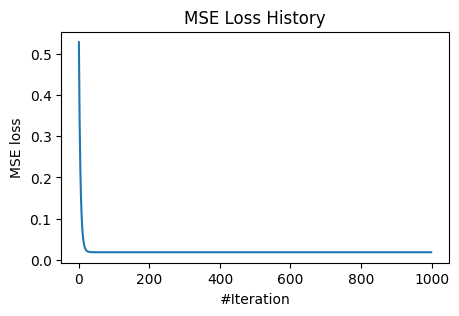

In [20]:
loss_history = myModel.MSE_loss_history
plt.figure(figsize=(5, 3))
sns.lineplot(loss_history)
plt.title("MSE Loss History")
plt.xlabel("#Iteration")
plt.ylabel("MSE loss")
plt.show()

## Calculating metrics

### MSE

In [21]:
y_output = myModel.predict(X_test, theta)
total_value = 0
total_numbers = len(X_test)

for i in range(total_numbers):
    total_value += (y_output[i] - y_test[i])**2

total_value = total_value / total_numbers

print(f"The MSE value is: {total_value[0]:.2f}")

The MSE value is: 0.07


### RMSE

In [22]:
print(f"The RMSE value is: {np.sqrt(total_value)[0]:.2f}")

The RMSE value is: 0.26


### MAE

In [23]:
y_output = myModel.predict(X_test, theta)
MAE = 0
total_numbers = len(X_test)

for i in range(total_numbers):
    MAE += np.abs(y_output[i] - y_test[i])

MAE = MAE / total_numbers

print(f"The MAE value is: {MAE[0]:.2f}")

The MAE value is: 0.23


## R-squared (R²)

In [24]:
SS_res = 0
SS_tot = 0

y_output = myModel.predict(X_test, theta)
R = 0
total_numbers = len(X_test)
y_mean = np.mean(y_test)

for i in range(total_numbers):
    SS_res = (y_output[i] - y_test[i])**2
    SS_tot = (y_test[i] - y_mean)**2

R = 1 - (SS_res / SS_tot)

print(f"The R value is: {R[0]:.2f}")

The R value is: 0.99


### Adjusted R-squared

In [25]:
n = len(X_test)
p = 1

adjusted_r2 = 1 - (1-R)*(n-1)/(n-p-1)

print(f"The MAE value is: {adjusted_r2[0]:.2f}")

The MAE value is: 0.98


### MAPE

In [26]:
mape = np.mean(np.abs((np.array(y_test) - np.array(y_output)) / np.array(y_test))) * 100

print(f"The MAPE value is: {mape}")

The MAPE value is: 47.72186151938263


### Using sklearn model

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
y_predict = model.predict(X_test)

In [29]:
y_predict

array([[ 1.47613439],
       [-0.16712845],
       [ 0.98665184],
       [-0.0272763 ],
       [-0.76150012],
       [-0.58668493]])

### Metrics

In [30]:
# MSE

total_value = 0
total_numbers = len(X_test)

for i in range(total_numbers):
    total_value += (y_predict[i] - y_test[i])**2

total_value = total_value / total_numbers

print(f"The MSE value is: {total_value[0]:.2f}")

The MSE value is: 0.07


In [31]:
# RMSE

print(f"The RMSE value is: {np.sqrt(total_value)[0]:.2f}")

The RMSE value is: 0.26


In [32]:
# MAE

MAE = 0
total_numbers = len(X_test)

for i in range(total_numbers):
    MAE += np.abs(y_predict[i] - y_test[i])

MAE = MAE / total_numbers

print(f"The MAE value is: {MAE[0]:.2f}")

The MAE value is: 0.23


In [33]:
# R squared

SS_res = 0
SS_tot = 0

R = 0
total_numbers = len(X_test)
y_mean = np.mean(y_test)

for i in range(total_numbers):
    SS_res = (y_predict[i] - y_test[i])**2
    SS_tot = (y_test[i] - y_mean)**2

R = 1 - (SS_res / SS_tot)

print(f"The R value is: {R[0]:.2f}")

The R value is: 0.99


In [34]:
# Adjusted R-squared

n = len(X_test)
p = 1

adjusted_r2 = 1 - (1-R)*(n-1)/(n-p-1)

print(f"The MAE value is: {adjusted_r2[0]:.2f}")

The MAE value is: 0.98


In [35]:
# MAPE

mape = np.mean(np.abs((np.array(y_test) - np.array(y_predict)) / np.array(y_test))) * 100

print(f"The MAPE value is: {mape}")


The MAPE value is: 47.72186151938263
